# Exploratory Data Analysis and Visualisation on the Titanic Dataset

I will analyze the Titanic dataset, focusing on understanding the factors that contributed to survival. My goal is to explore the data using various visualizations and statistical methods.

# Imports and Setup

I am using pandas for data manipulation, numpy for numerical operations, matplotlib and seaborn for visualization. I'll set a dark grid theme for the plots as well because dark is cool.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

# Loading the dataset

I'll start by loading the train.csv file into a pandas DataFrame and inspecting the first few rows and overall information to understand its structure, column types, and missing values.

In [2]:
df = pd.read_csv("../Datasets/Visualisation1/train.csv")
df = df.drop("PassengerId", axis=1)
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Data Cleaning and Preparation

I need to handle the missing values and prepare the data for analysis. The Age and Embarked columns have some missing entries, and the Cabin column is mostly empty, so I will drop it. I also convert categorical 'Sex' and 'Embarked' features into numerical representations.

In [3]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop("Cabin", axis=1)

In [4]:
df["Sex"] = df["Sex"].map({"male":0, "female":1})
df["Embarked"] = df["Embarked"].map({"S":0, "C":1, "Q":2})

# Univariate Analysis

I'll start by looking at single variable distributions to understand the passenger demographics.

# Age Distribution

I will use both a line plot of sorted ages and a histogram to visualize how ages are distributed among passengers.

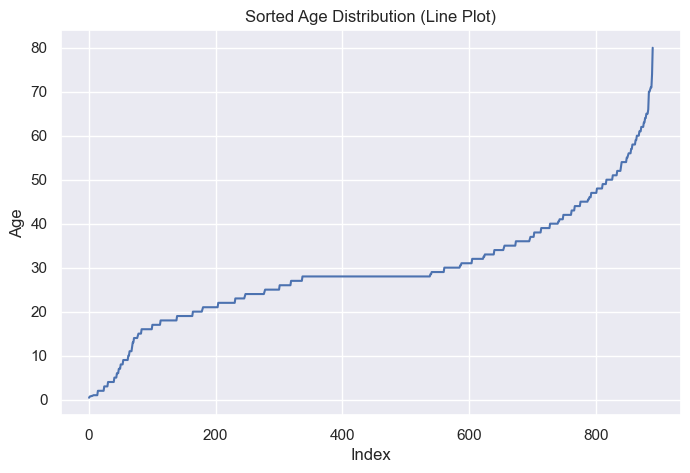

In [5]:
plt.figure(figsize=(8,5))
df["Age"].sort_values().reset_index(drop=True).plot()
plt.title("Sorted Age Distribution (Line Plot)")
plt.xlabel("Index")
plt.ylabel("Age")
plt.show()

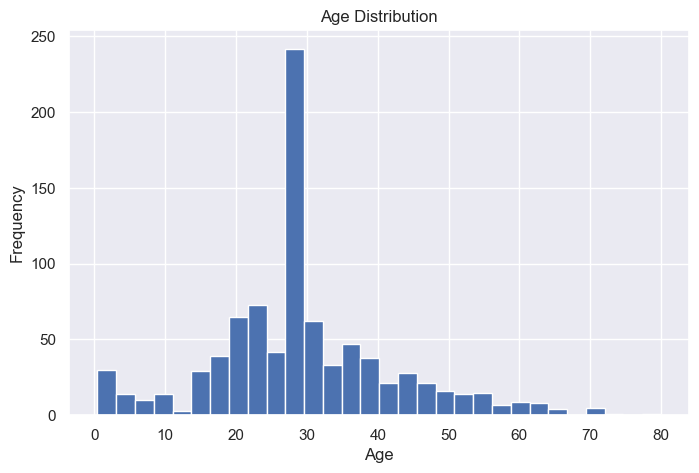

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Survival Distribution

This pie chart gives me a baseline survival rate for the entire dataset.

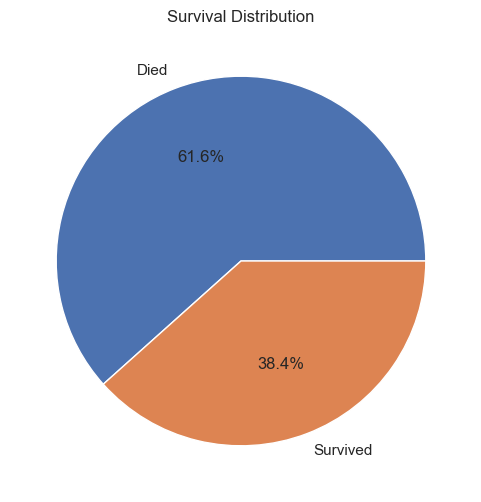

In [7]:
survival_counts = df["Survived"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(survival_counts, labels=["Died", "Survived"], autopct="%1.1f%%")
plt.title("Survival Distribution")
plt.show()

# Bivariate Analysis

Now I will look at how different pairs of variables interact.

# Age vs Fare

I want to see if age and ticket fare have any clear relationship. The scatter plot reveals that most people paid low fares, but high fares were paid across various ages.


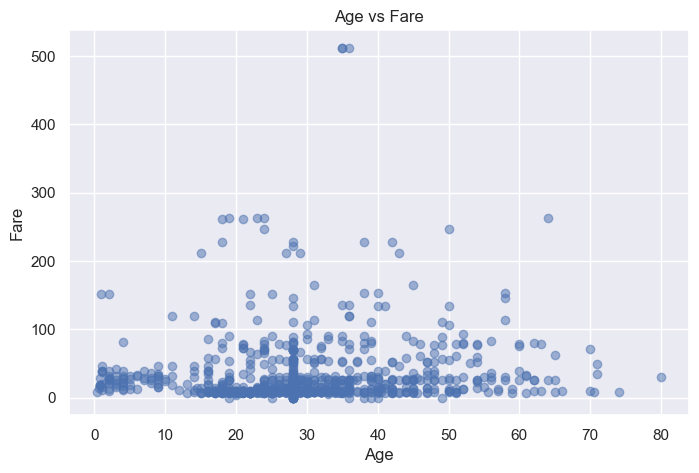

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(df["Age"], df["Fare"], alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare")
plt.show()

# Survival Factor Analysis

I am interested in which features actually impacted the survival rate.

# Fare Distribution by Survival

The boxplot helps visualize that survivors generally paid higher fares than non-survivors, which implies a link between socio-economic status (or cabin location) and survival chances.

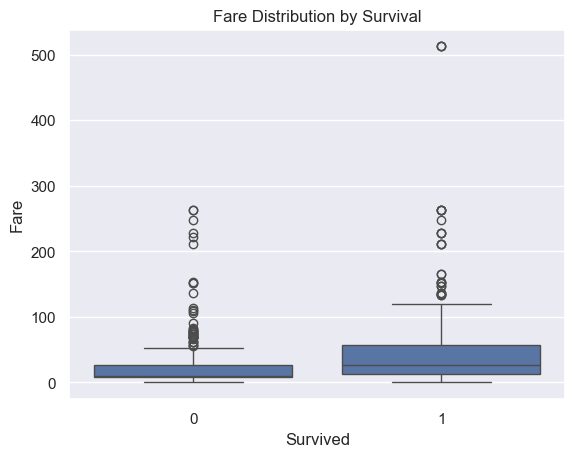

In [9]:
sns.boxplot(data=df, x="Survived", y="Fare")
plt.title("Fare Distribution by Survival")
plt.show()

# Survival Rate by Gender

The bar plot strongly supports historical accounts, showing a much higher survival rate for females than males.

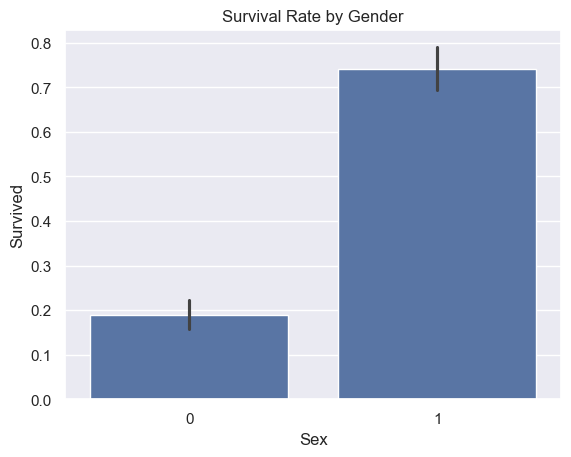

In [10]:
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Survival Rate by Gender")
plt.show()

# Survival Rate by Passenger Class

This plot shows that first-class passengers had a much better chance of survival than those in second or third class.

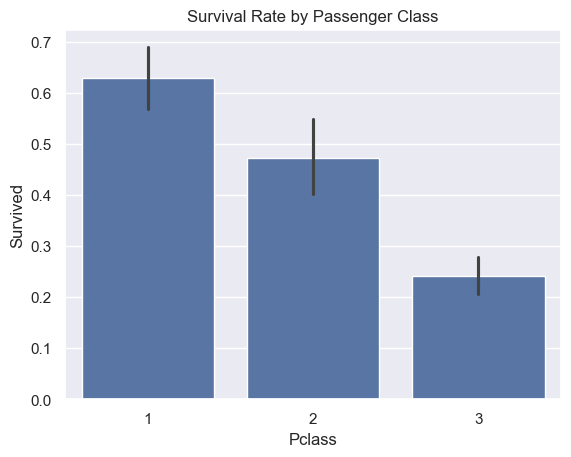

In [11]:
sns.barplot(x="Pclass", y="Survived", data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

# Age Density by Survival

The KDE plot helps visualize the density of survivors and non-survivors across different ages. The survival density (orange) has a distinct peak for young children.

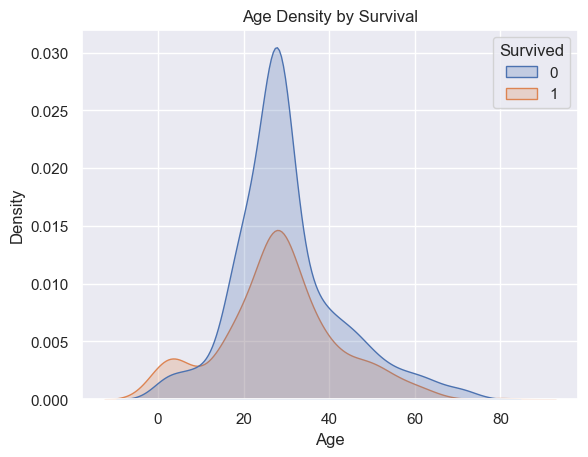

In [12]:
sns.kdeplot(data=df, x="Age", hue="Survived", fill=True)
plt.title("Age Density by Survival")
plt.show()

# Survival by Embarkation Port

I'm checking if the port of embarkation affected survival rates. This likely acts as a confounding variable tied to passenger class.

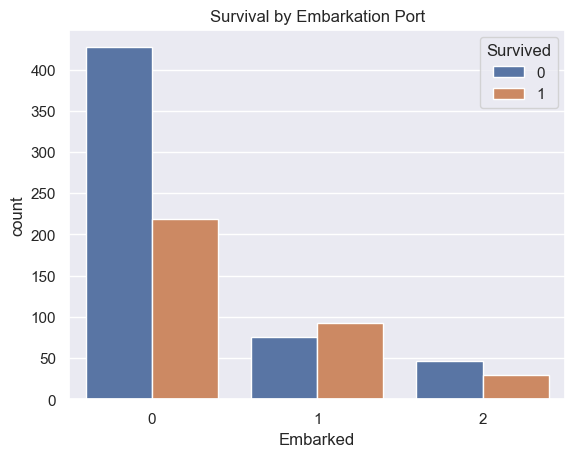

In [13]:
sns.countplot(x="Embarked", hue="Survived", data=df)
plt.title("Survival by Embarkation Port")
plt.show()

# Correlation and Feature Relationships

I want to quantify relationships between numerical variables using a correlation heatmap and visually inspect high-level relationships with a pairplot

# Correlation Heatmap

The heatmap clearly highlights key relationships. Sex has the strongest correlation with Survived (0.54), followed by Pclass and Fare.

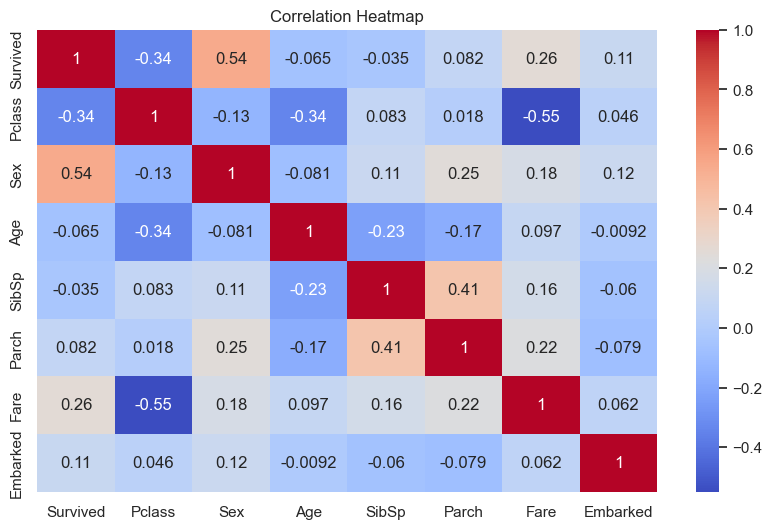

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Pairplot

This plot gives a holistic view of the key features and how survival (hue) separates the data points in each pair of dimensions.

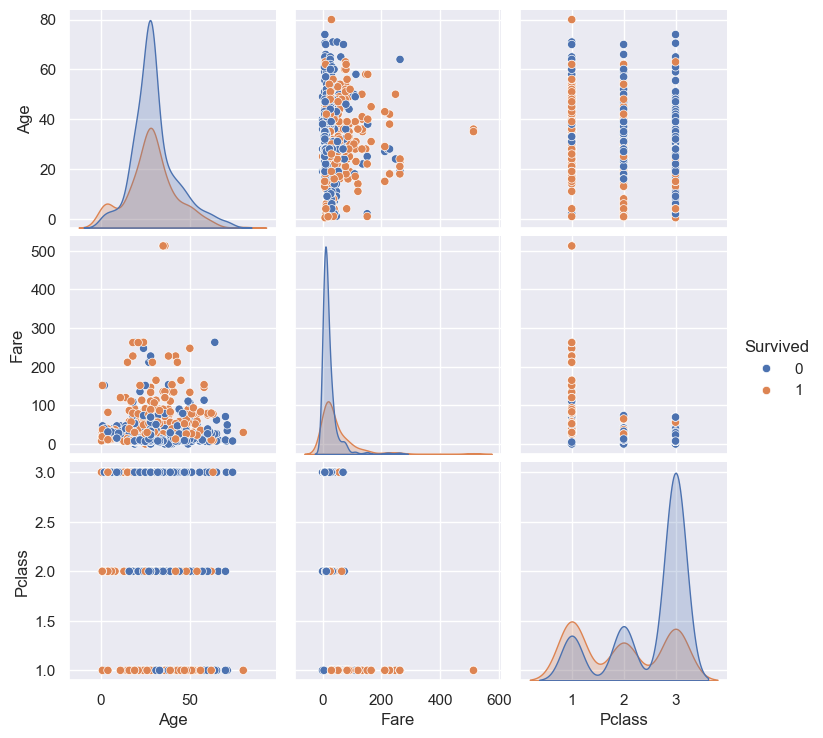

In [15]:
sns.pairplot(df[["Survived","Age","Fare","Pclass"]], hue="Survived")
plt.show()

Final Conclusions

> My exploratory data analysis successfully identified the primary drivers of survival on the Titanic: gender, passenger class, and age (specifically very young children).

> Gender was the single most predictive factor, with women being far more likely to survive than men.

> Socio-economic status (represented by Pclass and Fare) played a crucial role; first-class passengers had significantly higher survival rates.

> The age distribution plots confirmed that children had better survival chances.